In [1]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             52 bits physical, 57 bits virtual
  Byte Order:                Little Endian
CPU(s):                      192
  On-line CPU(s) list:       0-191
Vendor ID:                   AuthenticAMD
  Model name:                AMD EPYC 9684X 96-Core Processor
    CPU family:              25
    Model:                   17
    Thread(s) per core:      1
    Core(s) per socket:      96
    Socket(s):               2
    Stepping:                2
    Frequency boost:         enabled
    CPU(s) scaling MHz:      63%
    CPU max MHz:             3715.4290
    CPU min MHz:             1500.0000
    BogoMIPS:                5100.04
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ht s
                             yscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constan
                         

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
from scipy.optimize import fmin, minimize, LinearConstraint, Bounds

from efficient_fpt.multi_stage_cy import (
    compute_loss_parallel,
    print_num_threads,
    compute_tadaloss_parallel,
)

import sys, os

In [3]:
combined_pkl = "addm_data_all_kappa_20260220-230703.pkl"  # <-- adjust filename as needed

with open(combined_pkl, "rb") as f:
    all_data = pickle.load(f)
data_keys = sorted(all_data.keys())
print(f"Loaded combined pkl with {len(data_keys)} eta values: {data_keys}")

Loaded combined pkl with 10 eta values: [0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7000000000000001, 0.8, 0.9, 1.0]


In [4]:
num_data_list = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]

### Run maximum likelihood with aDDM likelihood function with different dataset size

In [5]:
paras_true_arr = np.zeros((len(num_data_list), len(data_keys), 4))
paras_mle_arr = np.zeros((len(num_data_list), len(data_keys), 4))

for i, data_name in enumerate(data_keys):
    for j, num_data in enumerate(num_data_list):
        data = all_data[data_name]
        a = data["a"]
        b = data["b"]
        x0 = data["x0"]
        eta_true = data["eta"]
        kappa_true = data["kappa"]
        r1_data = data["r1_data"][:num_data]
        r2_data = data["r2_data"][:num_data]
        flag_data = data["flag_data"][:num_data].astype(np.int32)
        sacc_data = data["sacc_array_padded_data"][:num_data, :]
        num_data, max_d = sacc_data.shape
        sigma = data["sigma"]
        T = data["T"]
        length_data = data["d_data"][:num_data].astype(np.int32)
        rt_data = data["decision_data"][:num_data, 0]
        choice_data = data["decision_data"][:num_data, 1].astype(np.int32)

        if j == 0:
            print(f"true params: [{eta_true:.2f}, {kappa_true:.2f}, {a:.2f}, {x0:.2f}]")

        # print("\nNumerical optimization for eta:")
        method = "trust-constr"
        # print("Using " + method)
        func = lambda paras: compute_loss_parallel(
            paras[1] * (r1_data - paras[0] * r2_data),
            paras[1] * (paras[0] * r1_data - r2_data),
            rt_data,
            choice_data,
            flag_data,
            sacc_data,
            length_data,
            max_d,
            sigma,
            paras[2],
            b,
            paras[3],
        )
        bounds = Bounds([0, 0, 0, -np.inf], [1, np.inf, np.inf, np.inf])
        con = LinearConstraint(
            [[0, 0, 1, 1], [0, 0, 1, -1]],
            lb=[0, 0],
            ub=[np.inf, np.inf],
        )
        initial_guess = [0.5, 0.5, 1.0, 0.0]
        # print("Initial guess:", initial_guess)
        # print()
        start_time = time.time()
        paras_opt_result = minimize(
            func,
            x0=initial_guess,
            bounds=bounds,
            constraints=con,
            method=method,
            options={"verbose": 0},
        )
        # print(f"Total time: {time.time() - start_time:.3f} seconds")
        if not paras_opt_result.success:
            print(f"WARNING: eta={eta_true} optimization failed.")
        mle = paras_opt_result["x"]
        paras_true_arr[j, i] = np.array([eta_true, kappa_true, a, x0])
        paras_mle_arr[j, i] = mle
        print(
            f"num_data: {num_data:5d},",
            f"mle: [{', '.join(f'{x:.5f}' for x in mle)}]",
        )

    print()

true params: [0.30, 0.10, 2.00, 0.50]
num_data:   100, mle: [0.73475, 0.16052, 2.21876, 0.68811]
num_data:   200, mle: [0.91078, 0.12731, 2.11416, 0.58723]
num_data:   400, mle: [0.43930, 0.12361, 2.02637, 0.45310]
num_data:   800, mle: [0.48319, 0.11611, 2.05541, 0.50899]
num_data:  1600, mle: [0.35399, 0.10609, 2.01744, 0.52243]
num_data:  3200, mle: [0.31046, 0.10850, 2.01377, 0.53254]
num_data:  6400, mle: [0.32565, 0.10033, 2.00261, 0.51455]
num_data: 12800, mle: [0.29240, 0.10222, 2.00148, 0.50558]
num_data: 25600, mle: [0.29977, 0.10364, 2.00680, 0.50621]

true params: [0.30, 0.20, 2.00, 0.50]
num_data:   100, mle: [0.40781, 0.26373, 2.11299, 0.59096]
num_data:   200, mle: [0.36802, 0.22799, 2.04908, 0.59494]
num_data:   400, mle: [0.38146, 0.23164, 2.01333, 0.53687]
num_data:   800, mle: [0.28152, 0.21150, 1.99410, 0.51279]
num_data:  1600, mle: [0.36622, 0.20626, 2.03164, 0.56554]
num_data:  3200, mle: [0.33714, 0.20017, 2.00375, 0.53154]
num_data:  6400, mle: [0.32724, 0.1952

### Run maximum likelihood with TADA likelihood function with different dataset size

In [6]:
paras_true_arr = np.zeros((len(num_data_list), len(data_keys), 4))
paras_tada_arr = np.zeros((len(num_data_list), len(data_keys), 4))

for i, data_name in enumerate(data_keys):
    for j, num_data in enumerate(num_data_list):
        data = all_data[data_name]
        a = data["a"]
        b = data["b"]
        x0 = data["x0"]
        eta_true = data["eta"]
        kappa_true = data["kappa"]
        r1_data = data["r1_data"][:num_data]
        r2_data = data["r2_data"][:num_data]
        flag_data = data["flag_data"][:num_data].astype(np.int32)
        sacc_data = data["sacc_array_padded_data"][:num_data, :]
        num_data, max_d = sacc_data.shape
        sigma = data["sigma"]
        T = data["T"]
        length_data = data["d_data"][:num_data].astype(np.int32)
        rt_data = data["decision_data"][:num_data, 0]
        choice_data = data["decision_data"][:num_data, 1].astype(np.int32)

        if j == 0:
            print(f"true params: [{eta_true:.2f}, {kappa_true:.2f}, {a:.2f}, {x0:.2f}]")

        # print("\nNumerical optimization for eta:")
        method = "trust-constr"
        # print("Using " + method)
        func = lambda paras: compute_tadaloss_parallel(
            paras[1] * (r1_data - paras[0] * r2_data),
            paras[1] * (paras[0] * r1_data - r2_data),
            rt_data,
            choice_data,
            flag_data,
            sacc_data,
            length_data,
            max_d,
            sigma,
            paras[2],
            b,
            paras[3],
        )
        bounds = Bounds([-np.inf, 0, 0, -np.inf], [np.inf, np.inf, np.inf, np.inf])
        con = LinearConstraint(
            [[0, 0, 1, 1], [0, 0, 1, -1]],
            lb=[0, 0],
            ub=[np.inf, np.inf],
        )
        initial_guess = [0.5, 0.5, 1.0, 0.0]
        # print("Initial guess:", initial_guess)
        # print()
        start_time = time.time()
        paras_opt_result = minimize(
            func,
            x0=initial_guess,
            bounds=bounds,
            constraints=con,
            method=method,
            options={"verbose": 0},
        )
        # print(f"Total time: {time.time() - start_time:.3f} seconds")
        if not paras_opt_result.success:
            print(f"WARNING: eta={eta_true} optimization failed.")
        mle = paras_opt_result["x"]
        paras_true_arr[j, i] = np.array([eta_true, kappa_true, a, x0])
        paras_tada_arr[j, i] = mle
        print(
            f"num_data: {num_data:5d}, "
            f"tada mle: [{', '.join(f'{x:.5f}' for x in mle)}]"
        )
    print()

true params: [0.30, 0.10, 2.00, 0.50]
num_data:   100, tada mle: [1.18412, 0.13329, 2.22017, 0.70107]
num_data:   200, tada mle: [0.99520, 0.12267, 2.11387, 0.58778]
num_data:   400, tada mle: [0.34242, 0.13184, 2.02226, 0.45333]
num_data:   800, tada mle: [0.36057, 0.12619, 2.05327, 0.51066]
num_data:  1600, tada mle: [0.18673, 0.12060, 2.01530, 0.52319]
num_data:  3200, tada mle: [0.13815, 0.12501, 2.01110, 0.53077]
num_data:  6400, tada mle: [0.16999, 0.11392, 1.99996, 0.51321]
num_data: 12800, tada mle: [0.15467, 0.11481, 1.99832, 0.50336]
num_data: 25600, tada mle: [0.18939, 0.11347, 2.00308, 0.50358]

true params: [0.30, 0.20, 2.00, 0.50]
num_data:   100, tada mle: [0.19221, 0.30686, 2.10353, 0.58539]
num_data:   200, tada mle: [0.23653, 0.24905, 2.04021, 0.59326]
num_data:   400, tada mle: [0.37315, 0.23177, 2.00115, 0.53017]
num_data:   800, tada mle: [0.21332, 0.22262, 1.97813, 0.50381]
num_data:  1600, tada mle: [0.27311, 0.22096, 2.02148, 0.55649]
num_data:  3200, tada mle: 

In [7]:
# save results

data_to_save = {
    "paras_true_arr": paras_true_arr,
    "paras_mle_arr": paras_mle_arr,
    "paras_tada_arr": paras_tada_arr,
}
fname = "tada_mle_result_" + time.strftime("%Y%m%d-%H%M%S") + ".pkl"

with open(fname, "wb") as f:
    pickle.dump(data_to_save, f)

In [8]:
# load results (if necessary)

results = pickle.load(open("tada_mle_result_20260221-111119.pkl", "rb")) # <-- adjust filename as needed
paras_true_arr = results["paras_true_arr"]
paras_mle_arr = results["paras_mle_arr"]
paras_tada_arr = results["paras_tada_arr"]

In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl

import os

if "/oscar/home/sliu167/texlive/2024/bin/x86_64-linux" not in os.environ["PATH"]:
    os.environ["PATH"] = (
        "/oscar/home/sliu167/texlive/2024/bin/x86_64-linux:" + os.environ["PATH"]
    )

mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amsfonts}"

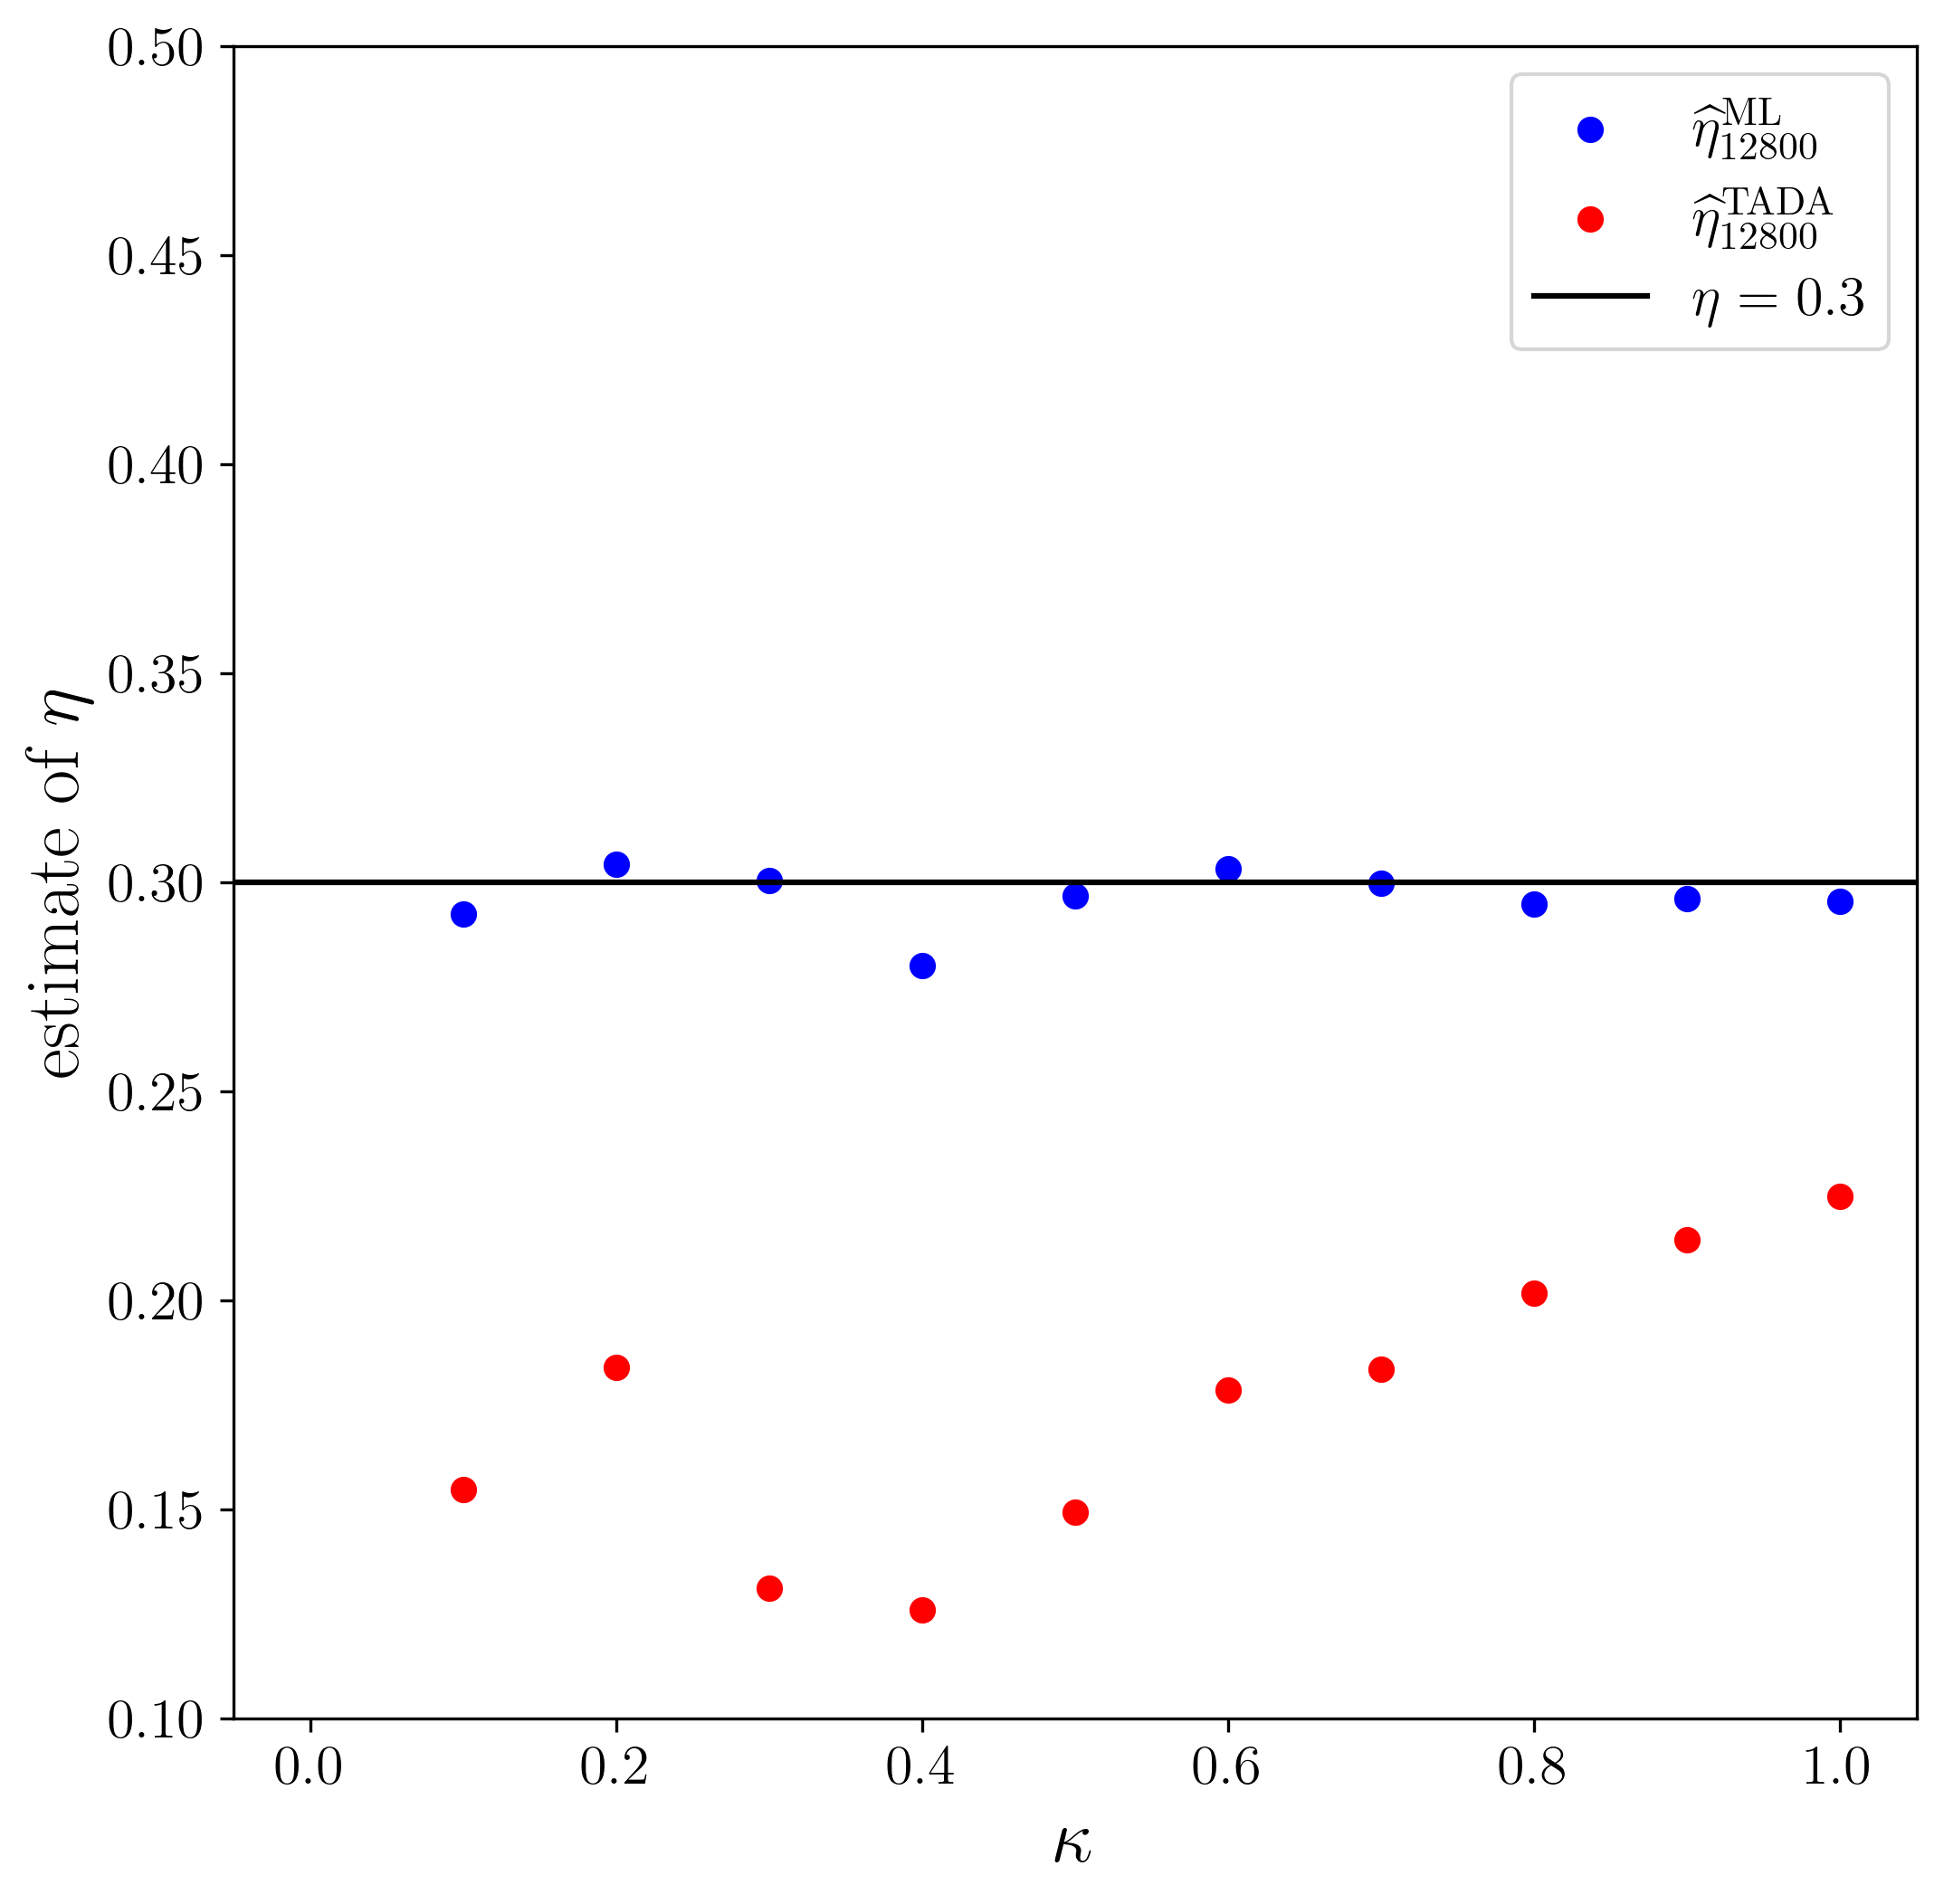

In [ ]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_mle_arr[num_data_idx, :, 0],
    label=rf"$\widehat{{\eta}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_tada_arr[num_data_idx, :, 0],
    label=rf"$\widehat{{\eta}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.axhline(paras_true_arr[num_data_idx, 0, 0], 0, 1, c="k", label=rf"$\eta={paras_true_arr[num_data_idx, 0, 0]}$")
ax.legend(fontsize=15)
ax.set_xlabel(r"$\kappa$", fontsize=20)
ax.set_ylabel(r"estimate of $\eta$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((-0.05, 1.05))
ax.set_ylim((0.1, 0.5))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()

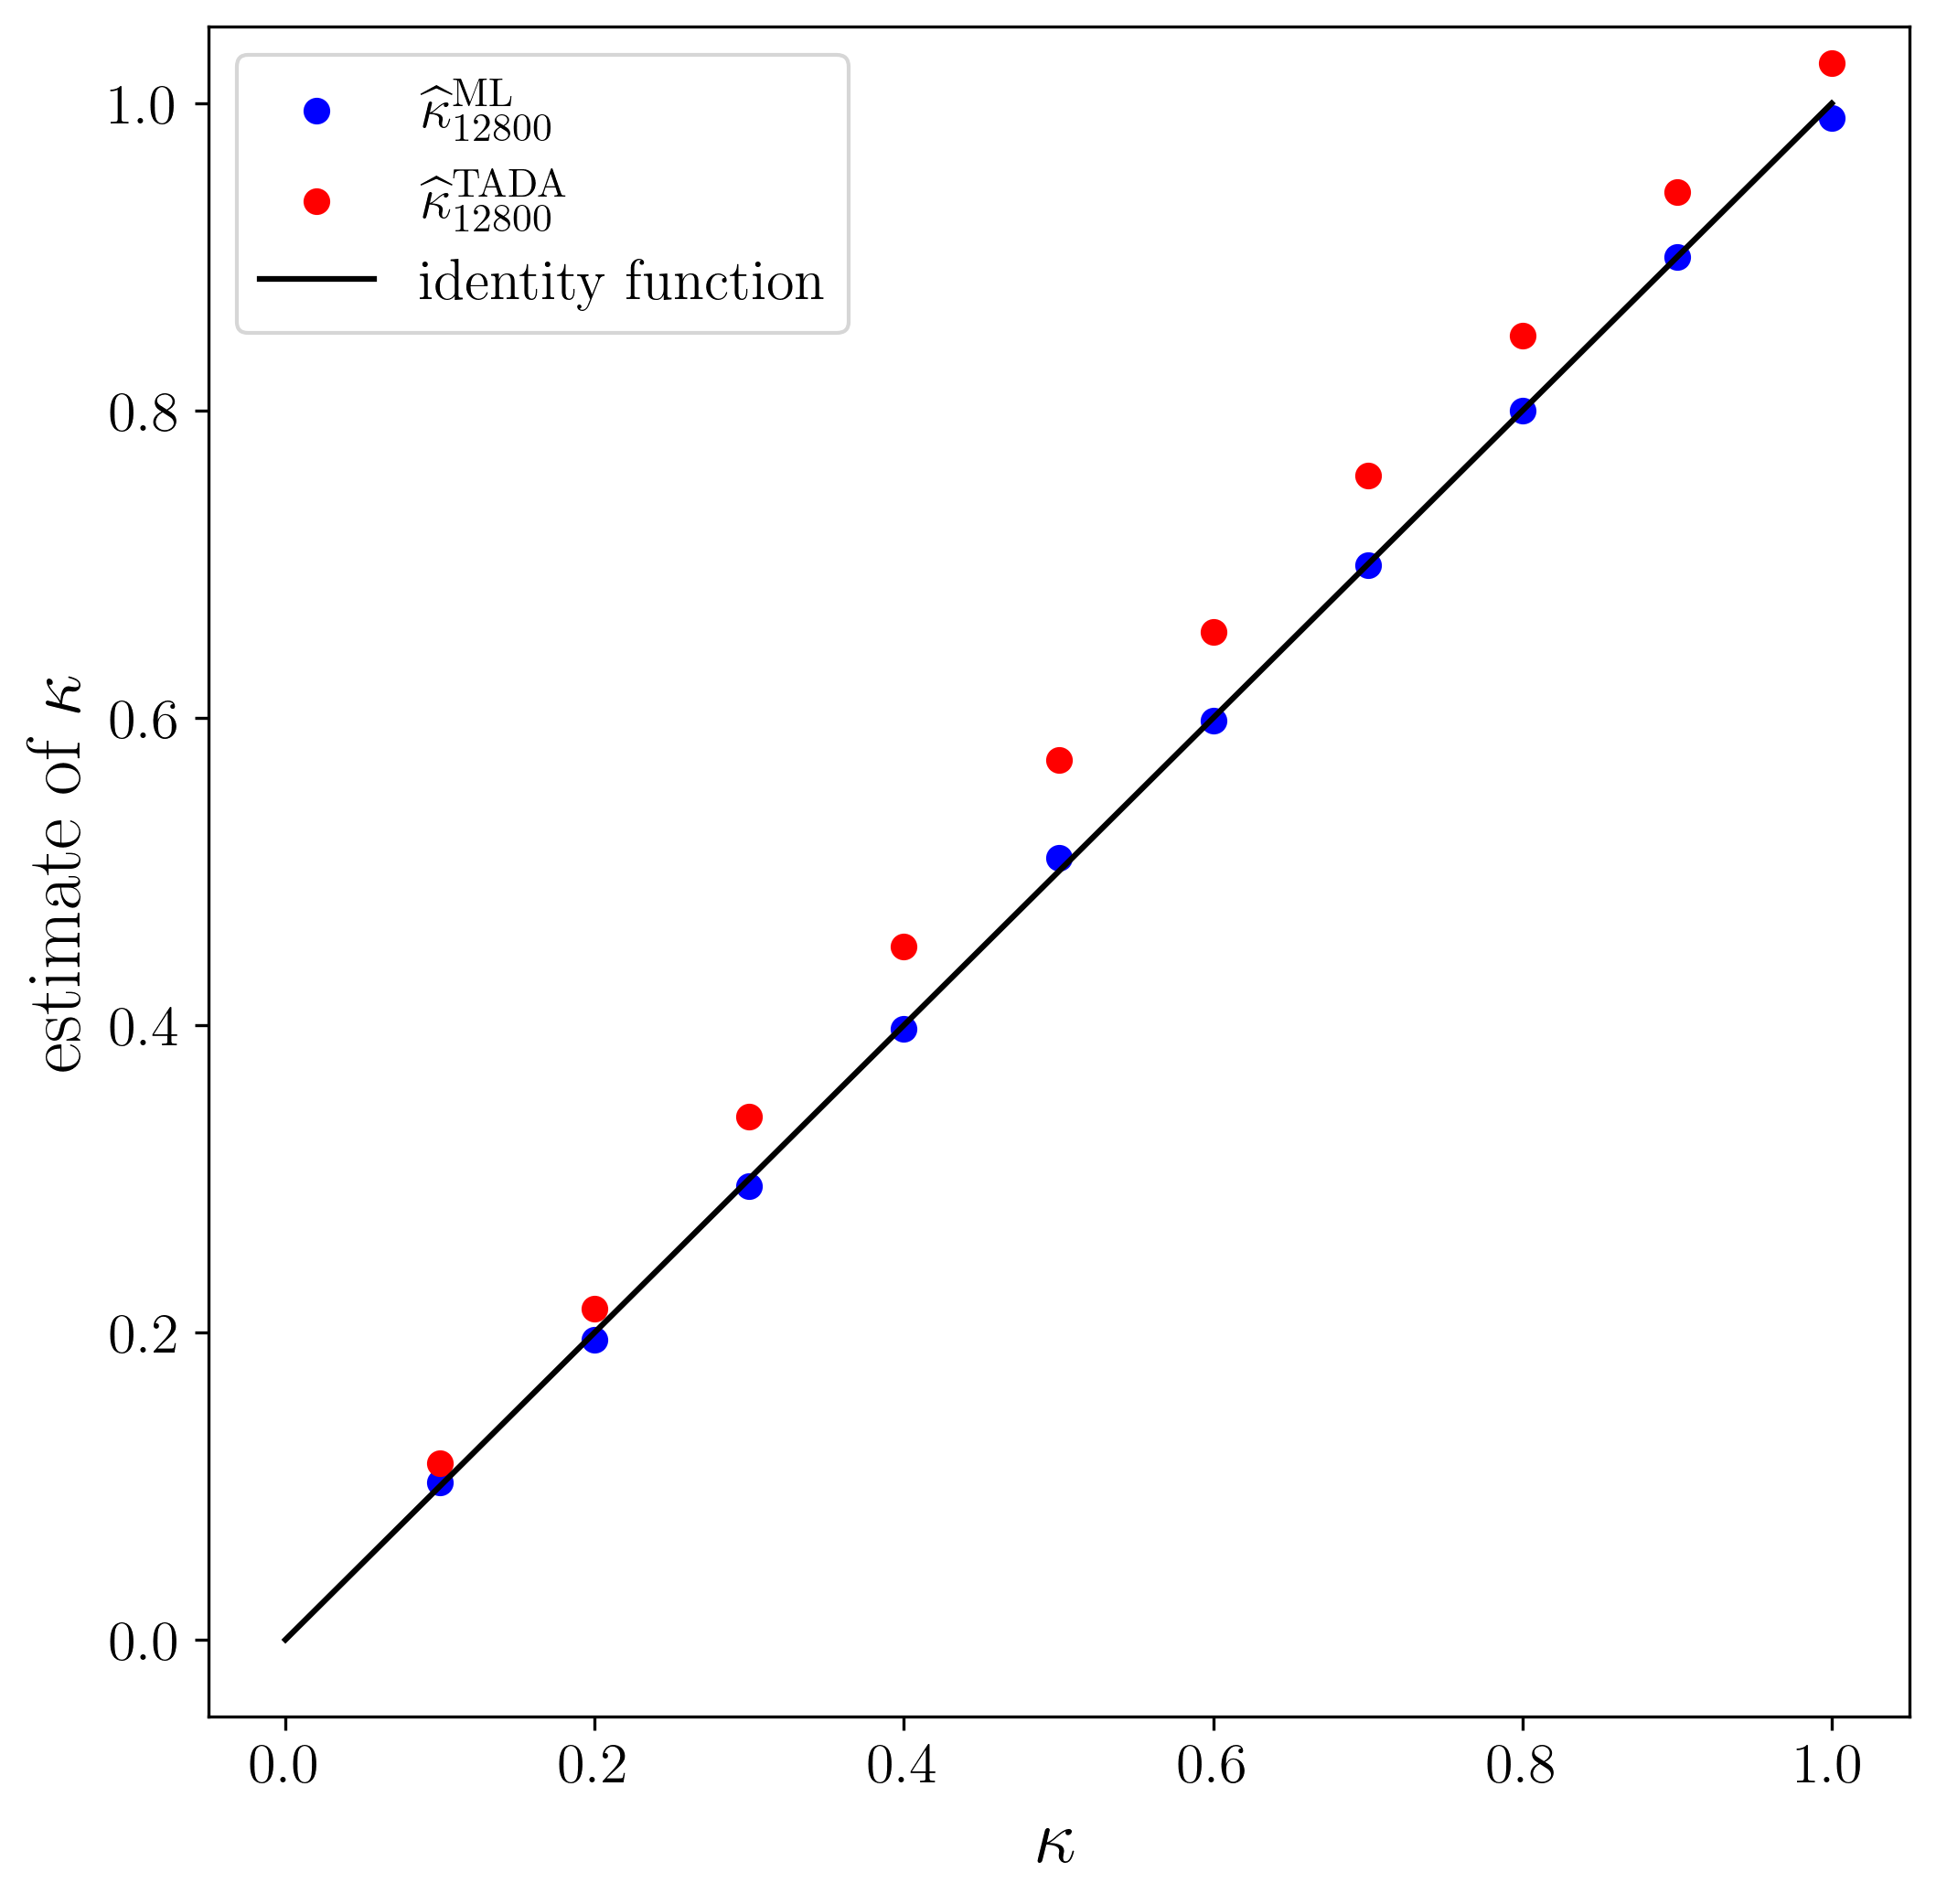

In [ ]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_mle_arr[num_data_idx, :, 1],
    label=rf"$\widehat{{\kappa}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_tada_arr[num_data_idx, :, 1],
    label=rf"$\widehat{{\kappa}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.plot(
    np.linspace(0, 1, 100), np.linspace(0, 1, 100), c="k", label="identity function"
)
ax.legend(fontsize=15)
ax.set_xlabel(r"$\kappa$", fontsize=20)
ax.set_ylabel(r"estimate of $\kappa$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((-0.05, 1.05))
ax.set_ylim((-0.05, 1.05))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()

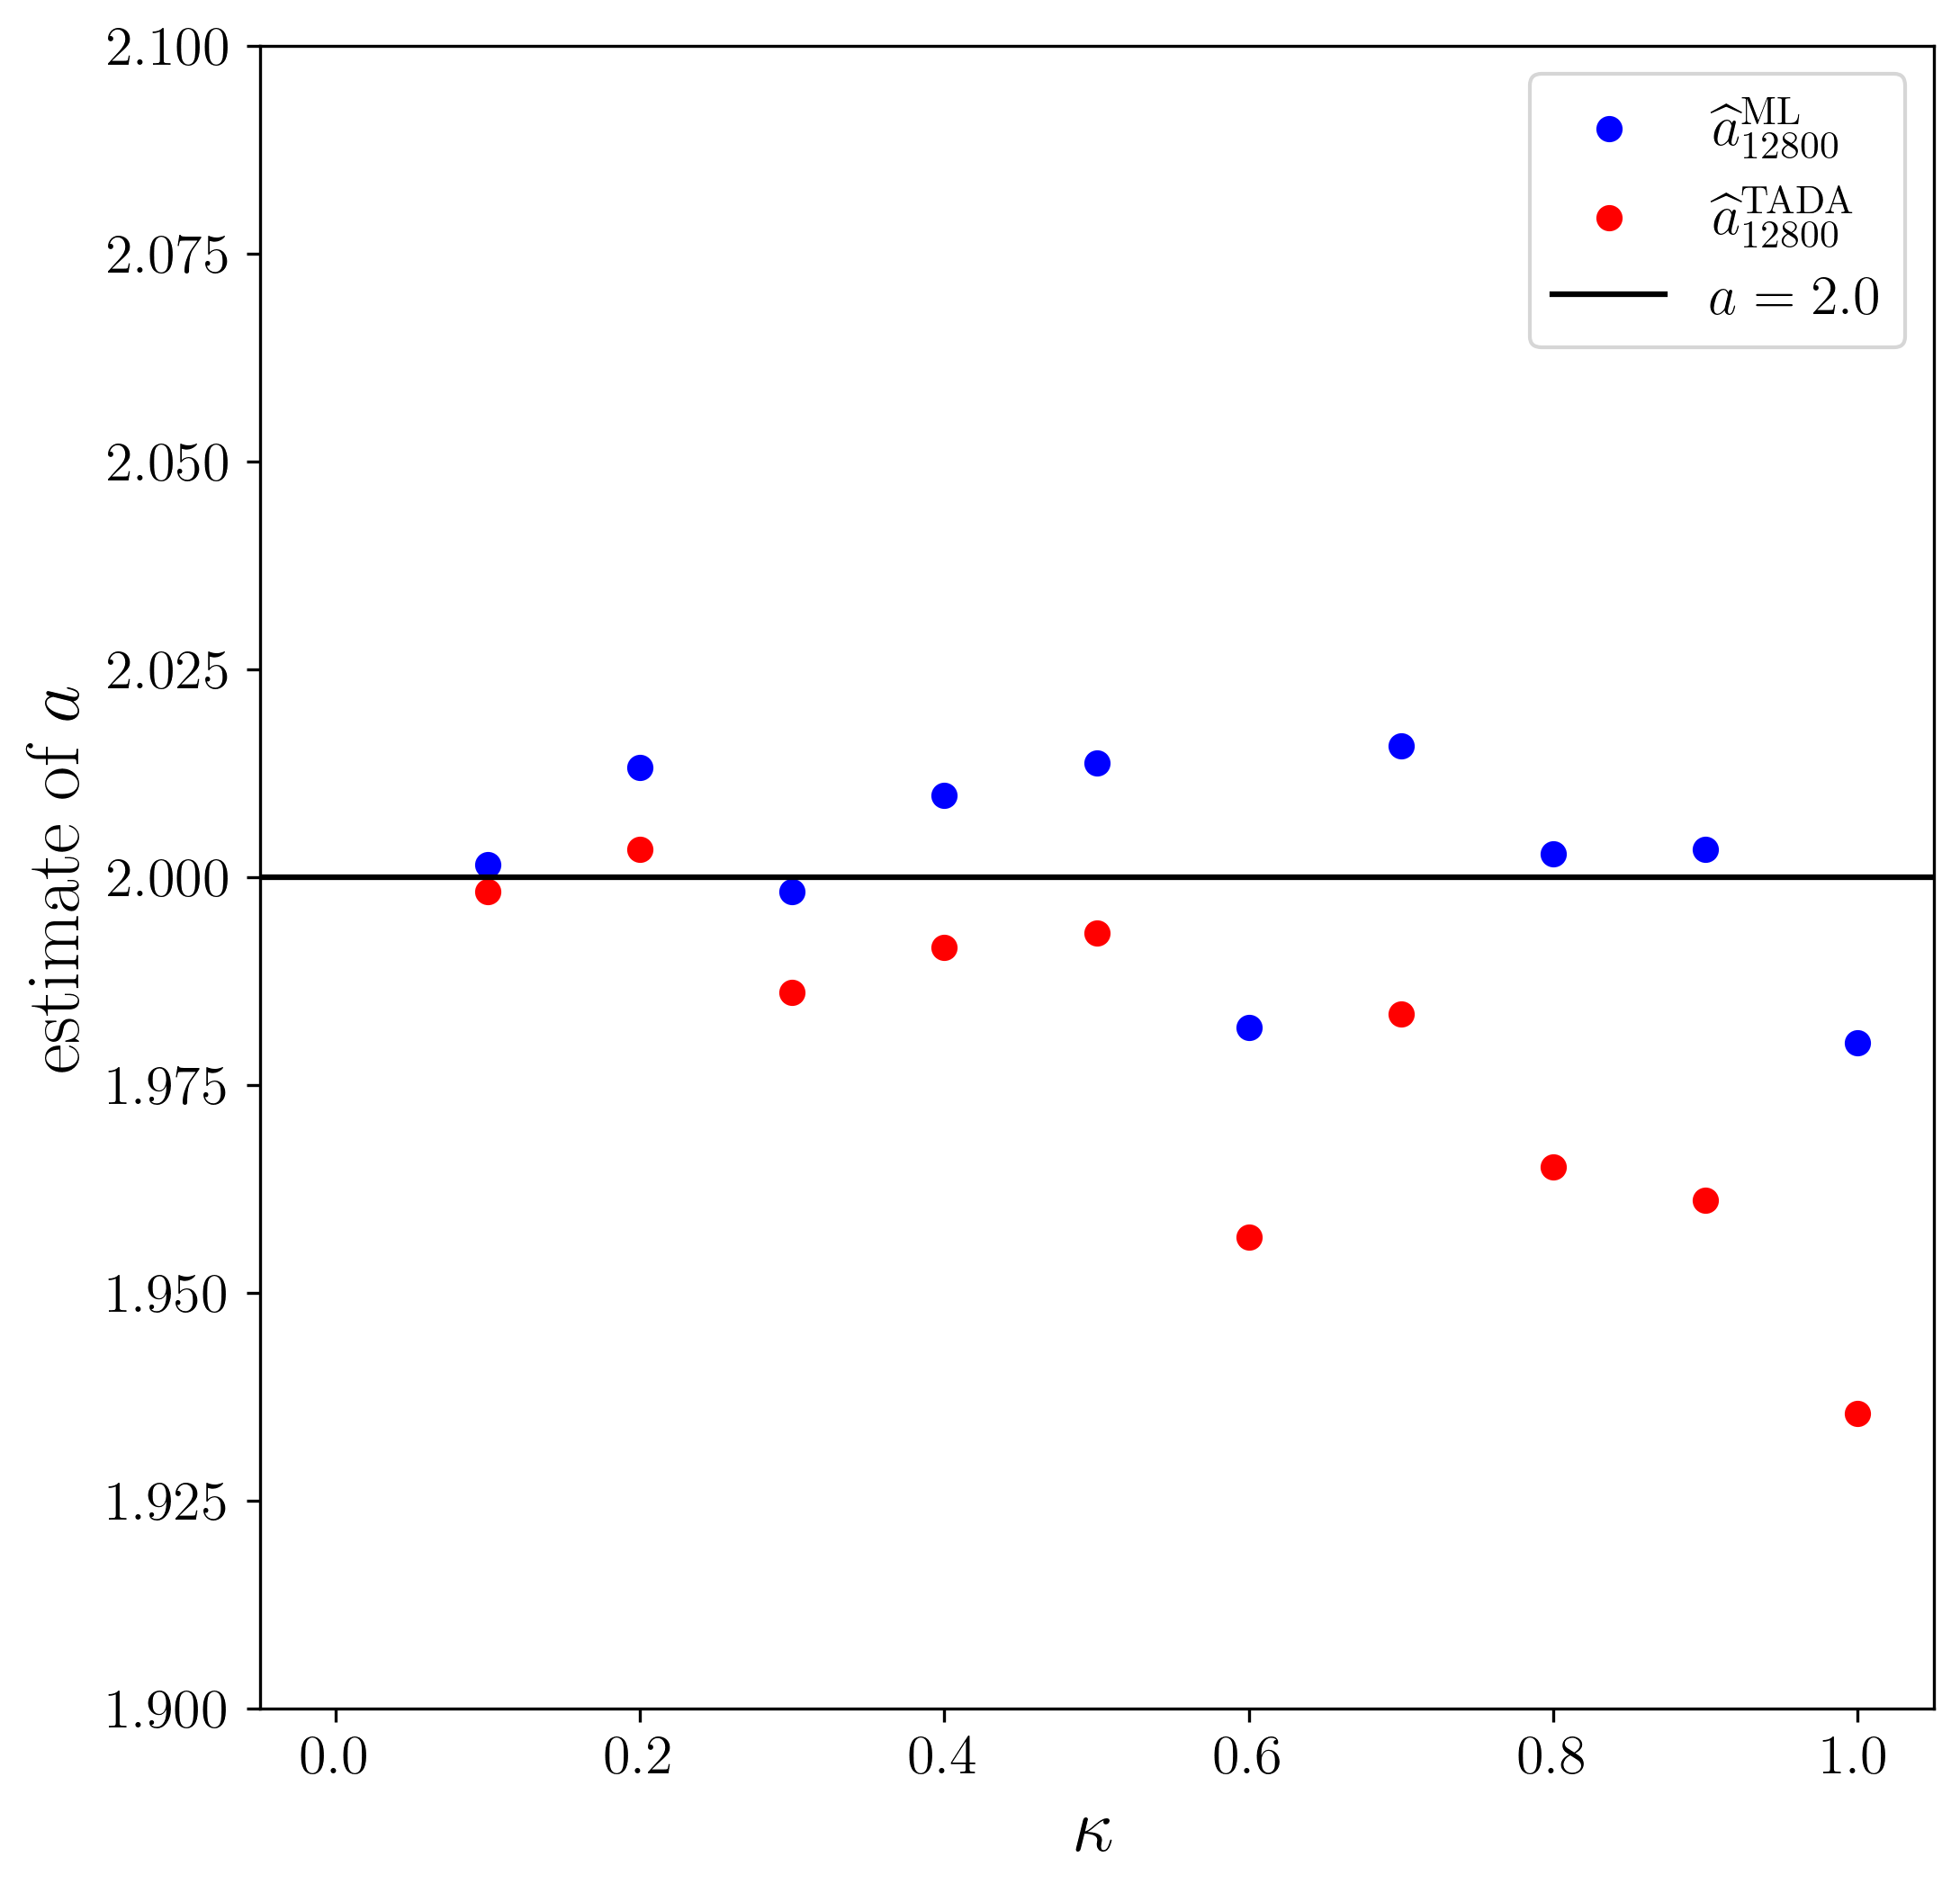

In [19]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_mle_arr[num_data_idx, :, 2],
    label=rf"$\widehat{{a}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_tada_arr[num_data_idx, :, 2],
    label=rf"$\widehat{{a}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.axhline(paras_true_arr[num_data_idx, 0, 2], 0, 1, c="k", label=rf"$a={paras_true_arr[num_data_idx, 0, 2]}$")
ax.legend(fontsize=15)
ax.set_xlabel(r"$\kappa$", fontsize=20)
ax.set_ylabel(r"estimate of $a$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((-0.05, 1.05))
ax.set_ylim((1.9, 2.1))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()

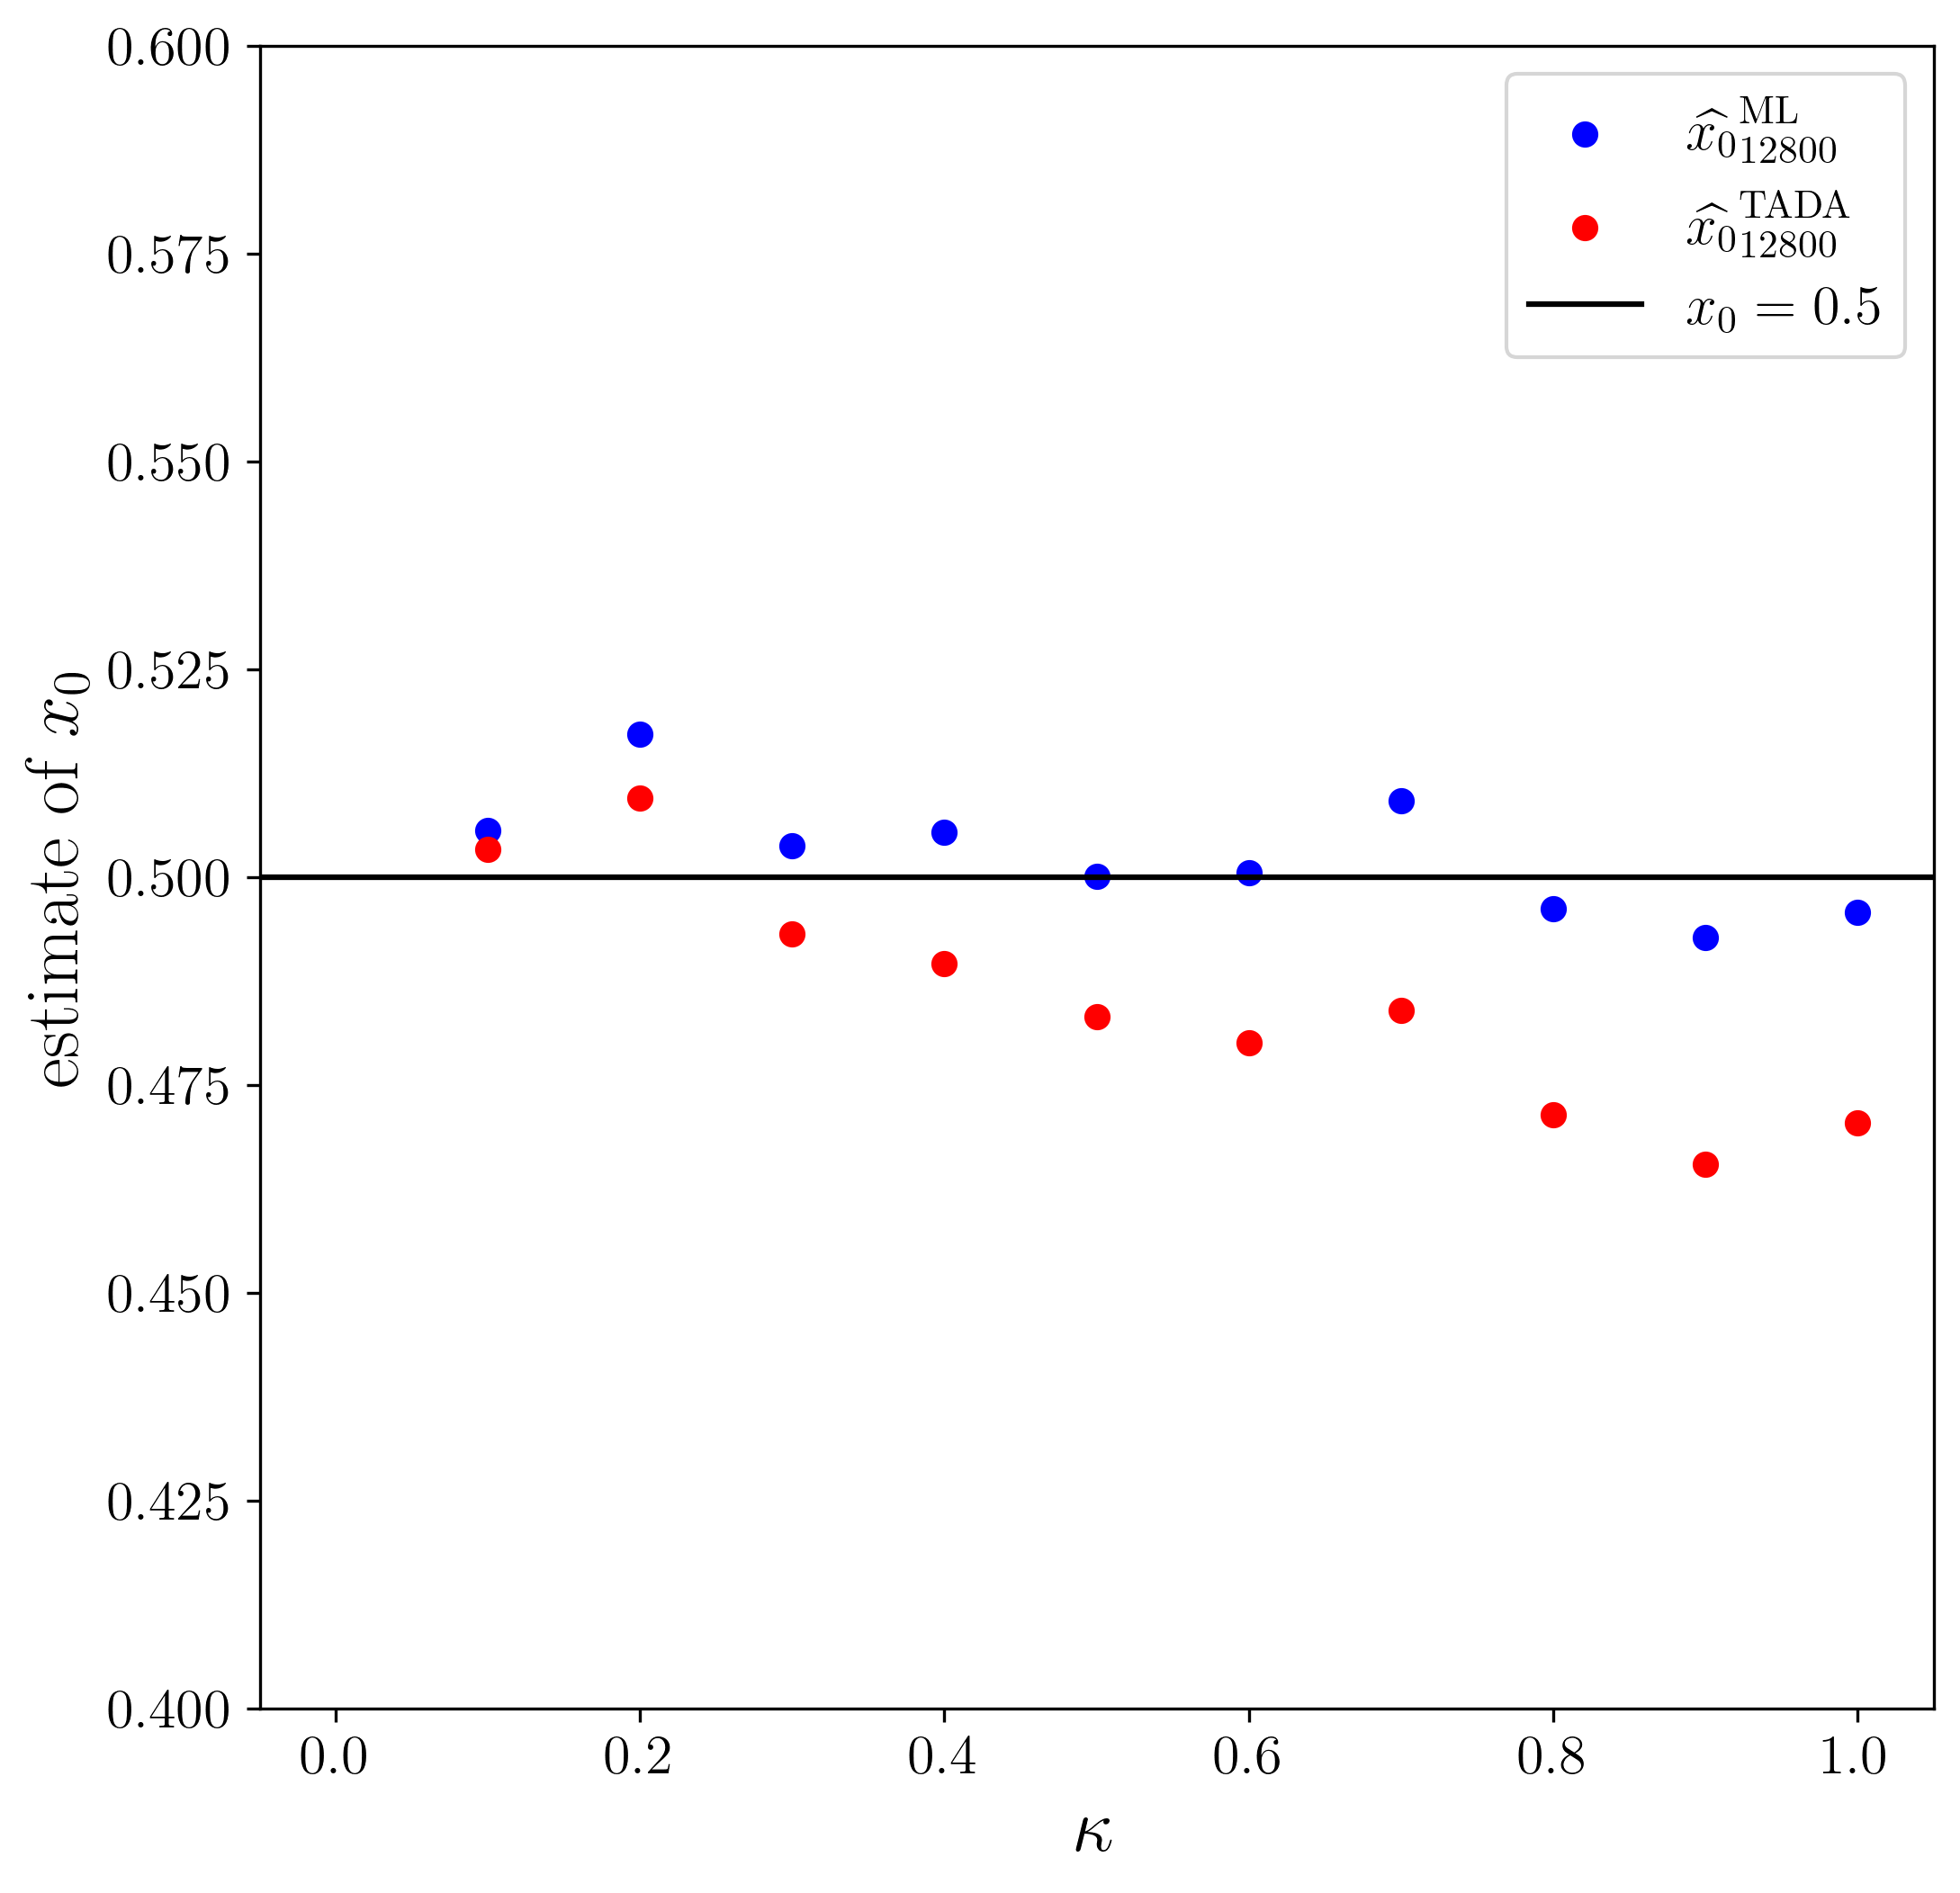

In [20]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_mle_arr[num_data_idx, :, 3],
    label=rf"$\widehat{{x_0}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_tada_arr[num_data_idx, :, 3],
    label=rf"$\widehat{{x_0}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.axhline(paras_true_arr[num_data_idx, 0, 3], 0, 1, c="k", label=rf"$x_0={paras_true_arr[num_data_idx, 0, 3]}$")
ax.legend(fontsize=15)
ax.set_xlabel(r"$\kappa$", fontsize=20)
ax.set_ylabel(r"estimate of $x_0$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((-0.05, 1.05))
ax.set_ylim((0.4, 0.6))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()